In [ ]:
conda activate workshop   

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#pip install matplotlib-venn
from matplotlib_venn import venn3

In [1]:
DATADIR = "/Users/katst103/Documents/Python_course_2025/CCD-project/" 

In [ ]:
##download input files:
rsync -ah kteng@rackham.uppmax.uu.se:/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/CrossSpeciesBMI/Data/outputs/DEP_ONLY_hierarchy_full_GO_enrichment.tsv .
rsync -ah kteng@rackham.uppmax.uu.se:/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/CrossSpeciesBMI/Data/outputs/DEP_CCD_hierachy_full_GO_enrichment.tsv .

rsync -ah kteng@rackham.uppmax.uu.se:/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/CrossSpeciesBMI/Data/outputs/OCD_ONLY_hierachy_full_GO_enrichment.tsv .
rsync -ah kteng@rackham.uppmax.uu.se:/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/CrossSpeciesBMI/Data/outputs/Compulsive_hierachy_full_GO_enrichment_251023.tsv .

rsync -ah kteng@rackham.uppmax.uu.se:/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/CrossSpeciesBMI/Data/outputs/SCH_ONLY_hierachy_full_GO_enrichment.tsv .
rsync -ah kteng@rackham.uppmax.uu.se:/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/CrossSpeciesBMI/Data/outputs/SCH_CCD_hierachy_full_GO_enrichment.tsv .

In [3]:
# DEP
dep1 = pd.read_csv(DATADIR+"DEP_ONLY_hierarchy_full_GO_enrichment.tsv",
                   sep="\t", index_col=0)
dep2 = pd.read_csv(DATADIR+"DEP_CCD_hierachy_full_GO_enrichment.tsv",
                   sep="\t", index_col=0)

dep1['run'] = 'DEP_ONLY'
dep2['run'] = 'DEP_CCD'
dep = pd.concat([dep1, dep2], ignore_index=True)

# OCD
ocd1 = pd.read_csv(DATADIR+"OCD_ONLY_hierachy_full_GO_enrichment.tsv",
                   sep="\t", index_col=0)
ocd2 = pd.read_csv(DATADIR+"Compulsive_hierachy_full_GO_enrichment_251023.tsv",
                   sep="\t", index_col=0)

ocd1['run'] = 'OCD_ONLY'
ocd2['run'] = 'OCD_CCD'
ocd = pd.concat([ocd1, ocd2], ignore_index=True)

# SCH
sch1 = pd.read_csv(DATADIR+"SCH_ONLY_hierachy_full_GO_enrichment.tsv",
                   sep="\t", index_col=0)
sch2 = pd.read_csv(DATADIR+"SCH_CCD_hierachy_full_GO_enrichment.tsv",
                   sep="\t", index_col=0)

sch1['run'] = 'SCH_ONLY'
sch2['run'] = 'SCH_CCD'
sch = pd.concat([sch1, sch2], ignore_index=True)

term_col = 'name'  # or 'native' if you prefer GO IDs

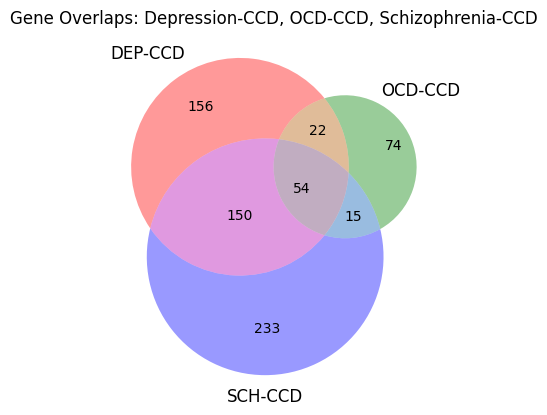

OCD: 165, SCH: 452, DEP: 382


In [4]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

def read_gene_file(filename):
    with open(filename, 'r') as f:
        return {line.strip() for line in f if line.strip()}

ocd_genes = read_gene_file(DATADIR+'ocd_ccd_systemsmap_genes.txt')
sch_genes = read_gene_file(DATADIR+'sch_ccd_systemsmap_genes.txt')
dep_genes = read_gene_file(DATADIR+'dep_ccd_systemsmap_genes.txt')

venn3([dep_genes,ocd_genes, sch_genes], set_labels=('DEP-CCD','OCD-CCD', 'SCH-CCD'))
plt.title('Gene Overlaps: Depression-CCD, OCD-CCD, Schizophrenia-CCD')
plt.savefig(DATADIR+"gene_venn.pdf", format='pdf', bbox_inches='tight', dpi=300)
plt.show()

print(f"OCD: {len(ocd_genes)}, SCH: {len(sch_genes)}, DEP: {len(dep_genes)}")

